In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
from PIL import Image
import pydicom
from scipy.ndimage import median_filter
from skimage import measure, morphology


In [5]:
import os
import glob

folder_path = "/mnt/nvme1n1/duong.quang.minh/LIDC/Image"

# Đếm tất cả các file trong thư mục (không đếm thư mục con)
file_count = len(glob.glob(folder_path + "/*"))

print(f"Số file trong thư mục: {file_count}")


Số file trong thư mục: 1010


In [3]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_dcom(file_path: str):
    return pydicom.dcmread(file_path)

def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val > 0:
        image = (image - min_val) / (max_val - min_val)

    return image

def lung_window_clip(array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = array.copy()
    clipped_array[clipped_array > max_px] = max_px
    clipped_array[clipped_array < min_px] = min_px
    return clipped_array

def plot_images(array_HU, array_Lung, title1="HU", title2="Lung"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(array_HU, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis("off")  # Hide axis

    axes[1].imshow(array_Lung, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis("off")  # Hide axis

def numpy_to_gif(image_array, mask_array, lung_array, folder_path="/data/hpc/dqm/3D-SegClass-Medical/assets", folder_name: str = "image", case_name: str = "3", duration=100):
    folder_path = folder_path + "/" + folder_name
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exist_ok=True)
        
    save_path_x = f"{folder_path}/{case_name}.gif"

    print(save_path_x)
    frames = []
    
    for i in range(image_array.shape[0]):
        img = Image.fromarray(scale_image(image_array[i, :, :]))
        lung = Image.fromarray(scale_image(lung_array[i, :, :]))
        mask = Image.fromarray(scale_image(mask_array[i, :, :]))
        
        combined = Image.new("L", (img.width * 3, img.height))
        combined.paste(img, (0, 0))
        combined.paste(mask, (mask.width, 0))
        combined.paste(lung, (lung.width * 2, 0))
        
        frames.append(combined)
        
    frames[0].save(save_path_x, save_all=True, append_images=frames[1:], duration=duration, loop=0)

def lung_window_clip_volume(pixel_array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = []
    for arr in pixel_array:
        clipped = arr.copy()
        clipped[clipped > max_px] = max_px
        clipped[clipped < min_px] = min_px
        clipped_array.append(clipped)
        
    return np.stack(clipped_array, axis = 0)

def numpy_to_gif_1_sample(array, folder_path="/data/hpc/dqm/3D-SegClass-Medical/assets", folder_name: str = "image", case_name: str = "3", duration=100):
    folder_path = folder_path + "/" + folder_name
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exists_ok=True)
        
    save_path_x = f"{folder_path}/{case_name}.gif"
    print(save_path_x)
    frames_x = []

    
    for i in range(array.shape[0]):
        img_x = Image.fromarray(scale_image(array[i, :, :])) 
        frames_x.append(img_x)

    frames_x[0].save(save_path_x, save_all=True, append_images=frames_x[1:], duration=duration, loop=0)


In [4]:
test = load_npy("/home/duong.quang.minh/project/3D-SegClass-Medical/data/Lung_Segmentation_v2/LIDC-IDRI-0016/0016_NI001.npy")
test.shape

(202, 256, 256)

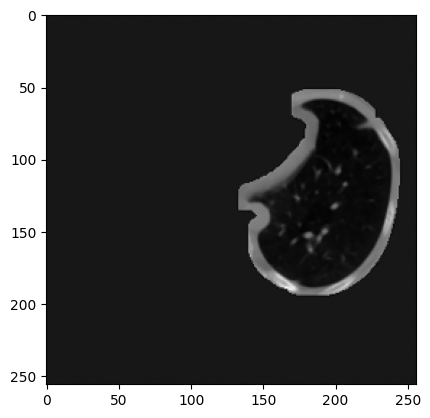

In [5]:
plt.imshow(test[0, :, :], cmap="gray")

In [4]:
def normalize_clipped(image, MIN_BOUND = -1000.0, MAX_BOUND = 400.0):
    image[image>MAX_BOUND] = MAX_BOUND
    image[image<MIN_BOUND] = MIN_BOUND
    return image

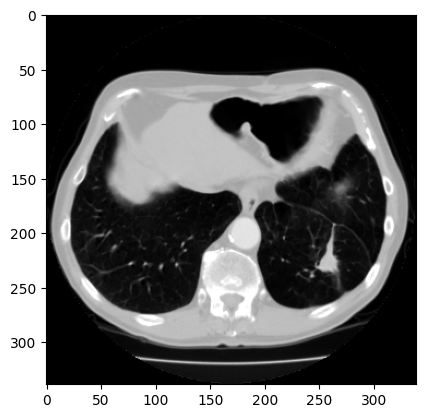

In [5]:
plt.imshow(normalize_clipped(test[99, :, :]), cmap="gray")

In [6]:
def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None
def segment_lung_mask(image, fill_lung_structures=True, threshhold: int = -320): # include structures within the lung
    
    binary_image = np.array(image > threshhold, dtype=np.int8) + 1
    labels = measure.label(binary_image, connectivity=3)
    
    background_label = labels[0,0,0]
    #Fill the air around the person
    binary_image[background_label == labels] = 2

    # Method of filling the lung structures (that is superior to something like 
    # morphological closing)
    if fill_lung_structures:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)
            
            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1
    
    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1

    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0

    return binary_image

In [7]:
b = segment_lung_mask(normalize_clipped(test), threshhold=-320, fill_lung_structures=True)

In [201]:
b, l = segment_lung_mask(normalize_clipped(test), threshhold=-320, fill_lung_structures=True)

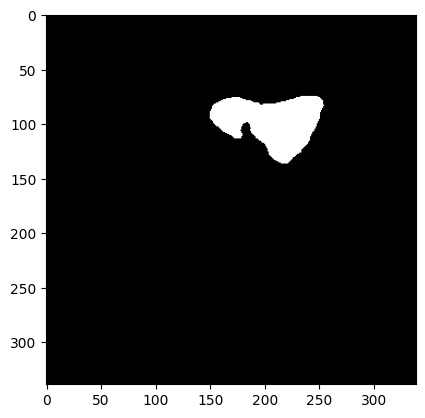

In [9]:
plt.imshow(b[99, :, :], cmap="gray")


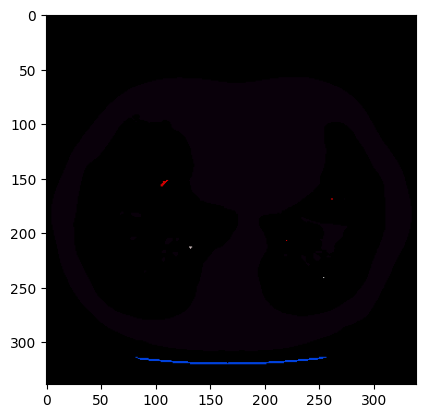

In [206]:
plt.imshow(labels[130, :, :], cmap='nipy_spectral')


In [209]:
background_label = l[0,0,0]
background_label

1

In [210]:
b[background_label == l] = 2
b

array([[[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       ...,

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 

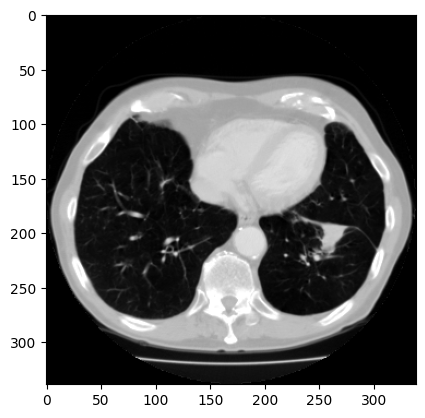

In [187]:
plt.imshow(test[130, :, :], cmap="gray")

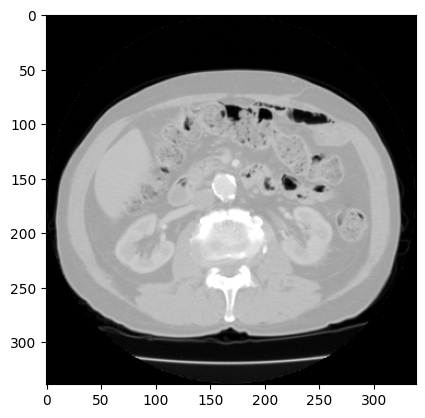

In [190]:
plt.imshow(test[0, :, :], cmap="gray")

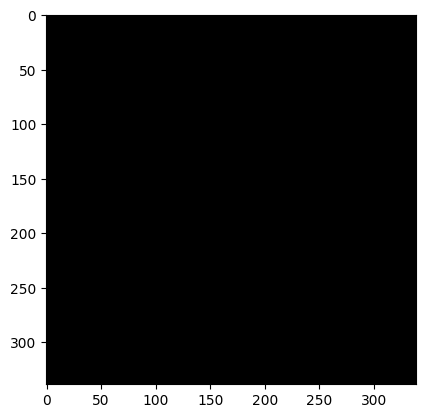

In [146]:
plt.imshow(b[130, :, :], cmap="gray")


In [147]:
numpy_to_gif_1_sample(b * 255, folder_name="vis", case_name="395_aaa")

/data/hpc/dqm/3D-SegClass-Medical/assets/vis/395_aaa.gif


In [ ]:
lst = [435, 481, 523, 539, 834, 837, 848, 849, 858, 860, 866, 877, 882, 890, 894, 906, 915, 928, 930, 933, 935, 942, 946, 950, 954, 957, 959, 969, 973, 980, 984, 995, 998, 999, 1006, 1007]
lst = [f"{i:04d}" for i in lst]

In [23]:
lst

['0834',
 '0837',
 '0848',
 '0849',
 '0858',
 '0860',
 '0866',
 '0877',
 '0882',
 '0890',
 '0894',
 '0906',
 '0915',
 '0928',
 '0930',
 '0933',
 '0935',
 '0942',
 '0946',
 '0950',
 '0954',
 '0957',
 '0959',
 '0969',
 '0973',
 '0980',
 '0984',
 '0995',
 '0998',
 '0999',
 '1006',
 '1007']

In [24]:
for case in lst:
    try:
        image = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-{case}/{case}_NI001.npy")
        lung = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation/LIDC-IDRI-{case}/{case}_NI001.npy")
        mask = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-{case}/{case}_MA001.npy")
    except Exception:
        image = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Clean/Image/LIDC-IDRI-{case}/{case}_CN001.npy")
        lung = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation/LIDC-IDRI-{case}/{case}_CN001.npy")
        mask = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Clean/Mask/LIDC-IDRI-{case}/{case}_CM001.npy")

    numpy_to_gif(image, mask * 255, lung, case_name=f"{case}", folder_name="all")

/data/hpc/dqm/3D-SegClass-Medical/assets/all/0834.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0837.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0848.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0849.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0858.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0860.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0866.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0877.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0882.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0890.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0894.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0906.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0915.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0928.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0930.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0933.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0935.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0942.gif
/data/hpc/dqm/3D-SegClass-Me

In [30]:
lst = [447, 479, 671, 894]
lst = [f"{i:04d}" for i in lst]
lst

['0447', '0479', '0671', '0894']

In [13]:
for case in ["0430", "0664", "0790", "0365"]:
    image = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-{case}/{case}_NI001.npy")
    lung = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation_v2/LIDC-IDRI-{case}/{case}_NI001.npy")
    mask = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-{case}/{case}_MA001.npy")

    print(image.shape)
    print(lung.shape)
    print(mask.shape)

    numpy_to_gif(image, mask * 255, lung, case_name=f"{case}_v3", folder_name="test")

(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0430_v3.gif


(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0664_v3.gif
(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0790_v3.gif
(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0365_v3.gif


In [10]:
lung.min()

-1.1546316

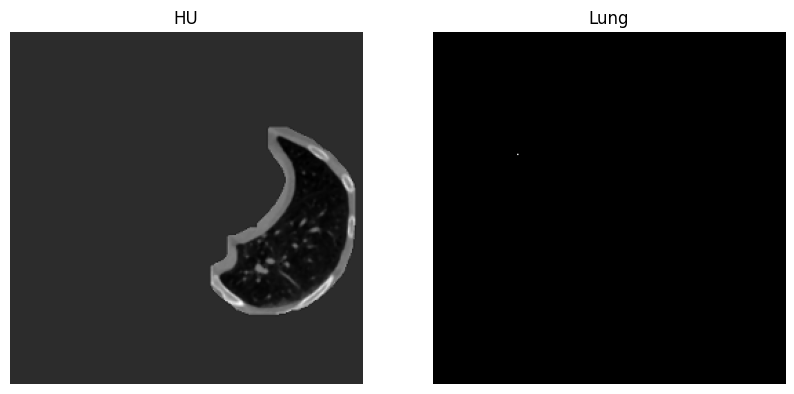

In [6]:
plot_images(lung[50, :, :], mask[90, :, :] * 255)

In [61]:
def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None
    
def denormalize_clipped(image, MIN_BOUND=-1000.0, MAX_BOUND=400.0):
    image = image * (MAX_BOUND - MIN_BOUND) + MIN_BOUND
    return image

def segment_lung_mask(image, fill_lung_structures=True): # include structures within the lung
    
    # not actually binary, but 1 and 2. 
    # 0 is treated as background, which we do not want
    binary_image = np.array(image > -320, dtype=np.int8)+1
    labels = measure.label(binary_image)

    background_label = labels[0,0,0]
    
    #Fill the air around the person
    binary_image[background_label == labels] = 2
    
    # Method of filling the lung structures (that is superior to something like 
    # morphological closing)
    if fill_lung_structures:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)
            
            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1
    
    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1
    
    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0
 
    return binary_image.astype(np.float32)

In [22]:
def make_lungmask_version_2(img):
    
    image_original = img.copy()
    
    row_size = img.shape[0]
    col_size = img.shape[1]

    mean = np.mean(img)
    std = np.std(img)
    img = img - mean
    img = img / std
    
    # Find the average pixel value near the lungs
    # to renormalize washed out images
    middle = img[int(col_size / 5):int(col_size / 5 * 4), int(row_size / 5):int(row_size / 5 * 4)]
    mean = np.mean(middle)
    max = np.max(img)
    min = np.min(img)
    # To improve threshold finding, I'm moving the
    # underflow and overflow on the pixel spectrum
    img[img == max] = mean
    img[img == min] = mean
    
    # apply median filter
    img = median_filter(img,size=3)
    #apply anistropic non-linear diffusion filter- This removes noise without blurring the nodule boundary
    img = anisotropic_diffusion(img)
    #
    # Using Kmeans to separate foreground (soft tissue / bone) and background (lung/air)
    #
    # kmeans = KMeans(n_clusters=2).fit(np.reshape(middle, [np.prod(middle.shape), 1]))
    # centers = sorted(kmeans.cluster_centers_.flatten())
    # threshold = np.mean(centers)
    # thresh_img = np.where(img < threshold, 1.0, 0.0)  # threshold the image
    
    thresh_img = segment_lung_mask(image_original)
    plt.imshow(thresh_img)

    # First erode away the finer elements, then dilate to include some of the pixels surrounding the lung.
    # We don't want to accidentally clip the lung.

    eroded = morphology.erosion(thresh_img, np.ones([3, 3]))
    dilation = morphology.dilation(eroded, np.ones([8, 8]))

    labels = measure.label(dilation)  # Different labels are displayed in different colors
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if B[2] - B[0] < row_size / 10 * 9 and B[3] - B[1] < col_size / 10 * 9 and B[0] > row_size / 5 and B[
            2] < col_size / 5 * 4:
            good_labels.append(prop.label)
    mask = np.ndarray([row_size, col_size], dtype=np.int8)
    mask[:] = 0

    #
    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask
    #
    for N in good_labels:
        mask = mask + np.where(labels == N, 1, 0)
    mask = morphology.dilation(mask, np.ones([10, 10]))  # one last dilation
    
    return mask * img # , mask: Lung Image, Mask

In [40]:
image_denormalized = denormalize_clipped(image)
print(image_denormalized.max())
print(image_denormalized.min())

400.0
-1000.0


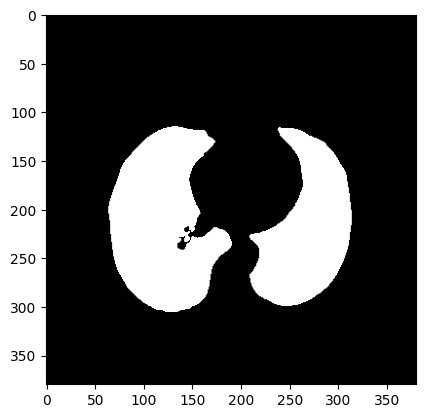

In [106]:
a = segment_lung_mask(test)
plt.imshow(a[140, :, :], cmap="gray")

In [107]:
result = []

for img, thresh_img in zip(test, a):
    row_size = img.shape[0]
    col_size = img.shape[1]

    mean = np.mean(img)
    std = np.std(img)
    img = img - mean
    img = img / std
    
    # Find the average pixel value near the lungs
    # to renormalize washed out images
    middle = img[int(col_size / 5):int(col_size / 5 * 4), int(row_size / 5):int(row_size / 5 * 4)]
    mean = np.mean(middle)
    max = np.max(img)
    min = np.min(img)
    # To improve threshold finding, I'm moving the
    # underflow and overflow on the pixel spectrum
    img[img == max] = mean
    img[img == min] = mean
    
    # apply median filter
    img = median_filter(img,size=3)
    #apply anistropic non-linear diffusion filter- This removes noise without blurring the nodule boundary
    img = anisotropic_diffusion(img)
    
    #
    # Using Kmeans to separate foreground (soft tissue / bone) and background (lung/air)
    #
    # kmeans = KMeans(n_clusters=2).fit(np.reshape(middle, [np.prod(middle.shape), 1]))
    # centers = sorted(kmeans.cluster_centers_.flatten())
    # threshold = np.mean(centers)
    # thresh_img = np.where(img < threshold, 1.0, 0.0)  # threshold the image

    # First erode away the finer elements, then dilate to include some of the pixels surrounding the lung.
    # We don't want to accidentally clip the lung.

    eroded = morphology.erosion(thresh_img, np.ones([3, 3]))
    dilation = morphology.dilation(eroded, np.ones([8, 8]))

    labels = measure.label(dilation)  # Different labels are displayed in different colors
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if B[2] - B[0] < row_size / 20 * 19 and B[3] - B[1] < col_size / 20 * 19 and B[0] > row_size / 10 and B[
            2] < col_size / 10 * 9:
            good_labels.append(prop.label)
    mask = np.ndarray([row_size, col_size], dtype=np.int8)
    mask[:] = 0

    #
    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask
    #
    for N in good_labels:
        mask = mask + np.where(labels == N, 1, 0)
    mask = morphology.dilation(mask, np.ones([10, 10]))  # one last dilation
    
    result.append(mask * img) # , mask: Lung Image, Mask
print(len(result))

320


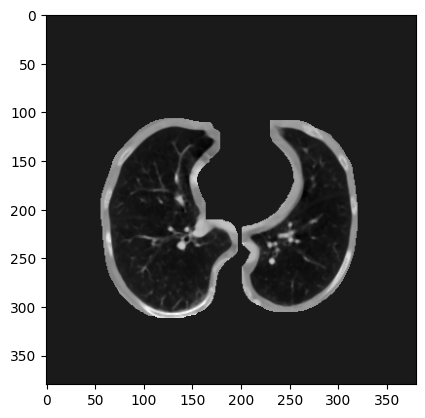

In [109]:
plt.imshow(result[140], cmap="gray")

In [111]:
numpy_to_gif(final, case_name="12_lung_v2_new", folder_name="test")

/data/hpc/dqm/3D-SegClass-Medical/assets/test/12_lung_v2_new_x.gif
